# Installations

In [61]:
!pip install pytesseract pillow numpy opencv-python matplotlib pandas requests jiwer

### Imports

In [62]:
import os
import re
import platform
import urllib.request
import requests

import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
import pytesseract

from PIL import Image
from jiwer import wer, cer

### Download models and Version Check

In [63]:
import os
import urllib.request
import pytesseract

pytesseract.pytesseract.tesseract_cmd = (
    r"C:\Program Files\Tesseract-OCR\tesseract.exe"
)

os.environ["TESSDATA_PREFIX"] = (
    r"C:\Program Files\Tesseract-OCR\tessdata"
)

models = {
    "eng": "https://github.com/tesseract-ocr/tessdata/raw/main/eng.traineddata",
}

for name, url in models.items():
    out = os.path.join(
        os.environ["TESSDATA_PREFIX"],
        f"{name}.traineddata"
    )

    if not os.path.exists(out):
        print(f"Downloading {name}...")
        urllib.request.urlretrieve(url, out)
    else:
        print(f"Already exists: {name}")

print("Done.")

Already exists: eng
Done.


In [64]:
print("Tesseract version:")
print(pytesseract.get_tesseract_version())

print("\nAvailable languages:")
print(pytesseract.get_languages())

Tesseract version:
5.5.0.20241111

Available languages:
['deu', 'deu_frak', 'eng', 'osd']


# Draw Bounding Box

In [65]:
"""
Oem(OCR Engine Mode):

0	Legacy Tesseract engine only
1	LSTM engine only
2	Legacy + LSTM
3	Default (let Tesseract decide)


psm(Page Segmentation Mode):

0	Orientation and Script Detection (OSD) only
1	Automatic page segmentation with OSD
2	Automatic page segmentation, no OCR, no OSD
3	Fully automatic page segmentation (default)
4	Assume a single column of text of variable sizes
5	Assume a single uniform block of vertically aligned text
6	Assume a single uniform block of text
7	Treat image as a single text line
8	Treat image as a single word
9	Treat image as a single word in a circle
10	Treat image as a single character
11	Sparse text. Find as much text as possible
12	Sparse text with OSD
13	Raw line mode (single line, bypasses some hacks)

"""

def draw_bounding_boxes(image_path, psm=4, min_conf=0):
    import cv2
    import pytesseract
    import matplotlib.pyplot as plt

    image = cv2.imread(image_path)

    data = pytesseract.image_to_data(
        image,
        lang="eng",
        config=f'--oem 1 --psm {psm}', # output oem 1(OCR Engine Mode 1: LSTM neural network OCR engine) psm(Page Segmentation Mode) 4
        output_type=pytesseract.Output.DICT
    )

    img_boxes = image.copy()

    for i in range(len(data["text"])):
        txt = data["text"][i].strip()

        try:
            conf = float(data["conf"][i])
        except:
            conf = -1

        if txt != "" and conf > min_conf:
            x = data["left"][i]
            y = data["top"][i]
            w = data["width"][i]
            h = data["height"][i]

            cv2.rectangle(
                img_boxes,
                (x, y),
                (x + w, y + h),
                (0, 255, 0),
                1
            )

    plt.figure(figsize=(8, 12))
    plt.imshow(img_boxes)
    plt.title(f"Detected Text Boxes: {image_path}")
    plt.axis("off")
    plt.show()

    #return img_boxes

### English Dataset Directory

In [66]:
ENG_IMAGES_DIR = "../../English_dataset/images_eng"
ENG_GOLD_DIR = "../../English_dataset/gold_english"

### Test image

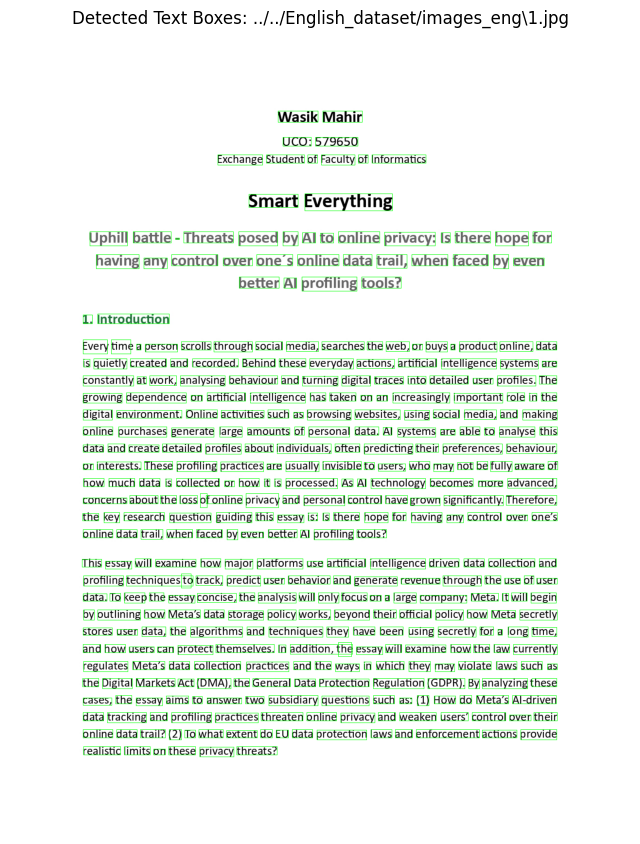

In [67]:
draw_bounding_boxes(os.path.join(ENG_IMAGES_DIR, "1.jpg"))

# Experiment 1 - Clean Baseline
Original image to OCR, Without preprocessing

In [68]:
import os

output_dir = "outputs/Experiment_1"
os.makedirs(output_dir, exist_ok=True)

In [69]:
def extract_text_pytesseract(image_path, psm=4, oem=1):

    image = cv2.imread(image_path)

    text = pytesseract.image_to_string(
        image,
        lang="eng",
        config=f'--oem 1 --psm {psm}'
    )

    return text

In [70]:
# test image
text = extract_text_pytesseract(os.path.join(ENG_IMAGES_DIR, "3.jpg"),psm=4,oem=1)

In [71]:
print(text)

In May 2023, another incident happened again with Lreland’s Data Protection Commission (DPC). The DPC
fined Meta €1.2 billion for mishandling the personal data of European users, marking the largest penalty ever
under the EU's General Data Protection Regulation (GDPR) [5]. The fine came after a long investigation into
how the company transferred user data from the EU to the United States of America without adequate
safeguards, despite a European Court of Justice ruling requiring strong protections for such transfers [5]. The
DPC found that Meta continued to send large volumes of Facebook users’ personal data to the USA on the basis
of standard contractual clauses (SCCs) that did not sufficiently protect individuals’ privacy rights, exposing
that data to potential access by US intelligence agencies. Because these clauses failed +o meet GDPR standards,
the regulator concluded that Meta was in breach of Article 46(1) of the GDFR [18], which governs secure
intemational data transfers [5]. 

### Extract text from all images

In [72]:
pages = [1,2,3,4,5,6] 


Page 1


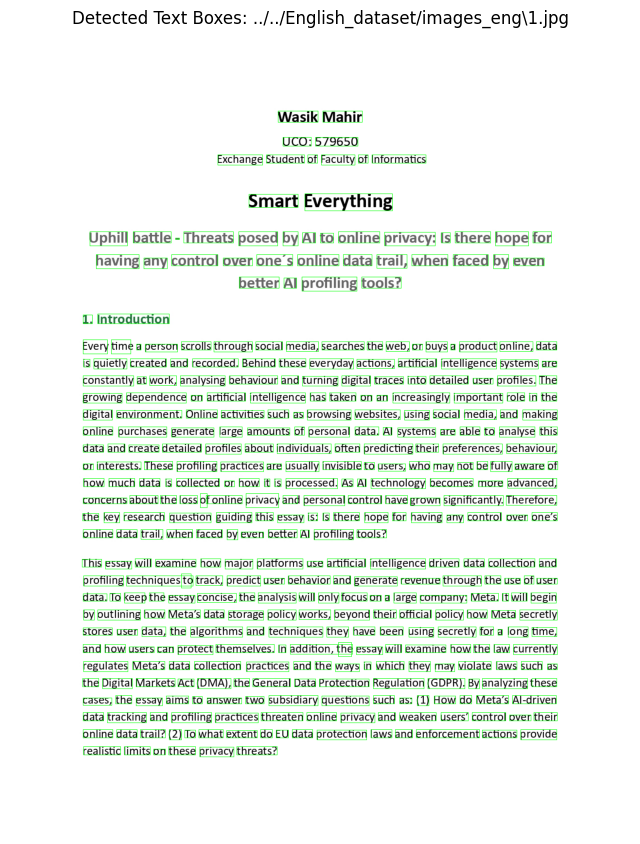

Wasik Mahir

UCO: 579650
Exchange Student of Faculty of Informatics

Smart Everything

Uphill battle - Threats posed by Al to online privacy: Is there hope for
having any control over one’s online data trail, when faced by even
better Al profiling tools?

1. Introduction

Every time a person scrolls through social media, searches the web, or buys a product online, data
is quietly created and recorded. Behind these everyday actions, artificial intelligence systems are
constantly at work, analysing behaviour and turning digital traces into detailed user profiles. The
growing dependence on artificial intelligence has taken on an increasingly important role in the
digital environment. Online activities such as browsing websites, using social media, and making
online purchases generate large amounts of personal data. Al systems are able to analyse this
data and create detailed profiles about individuals, often predicting their preferences, behaviour,
or interests. These profiling practices 

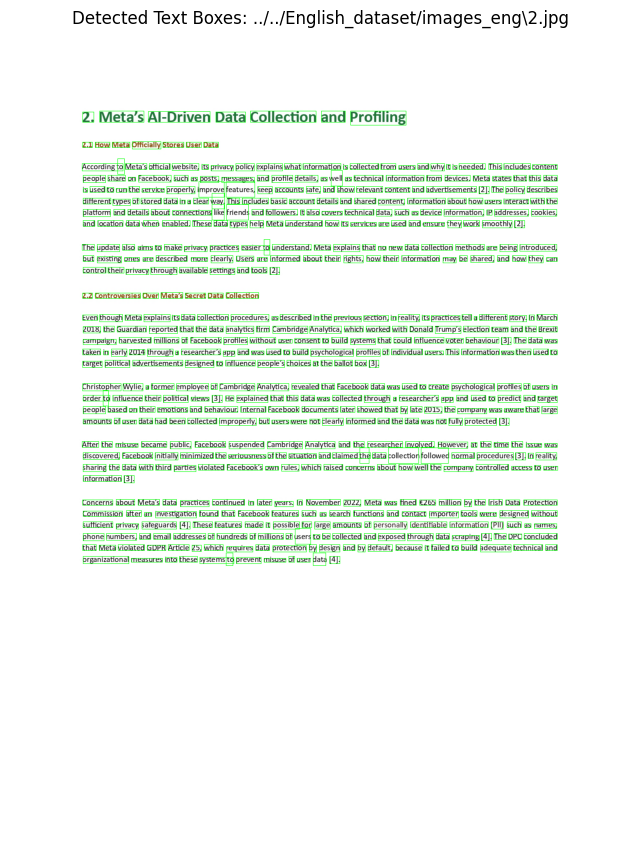

2. Meta’s Al-Driven Data Collection and Profiling

2.1 How Meta Officially Stores User Data

According to Meta’s official website, its privacy policy explains what information is collected from users and why it is needed. This includes content
people share on Facebook, such as posts, messages, and profile details, as well as technical information from devices. Meta states that this data
is used to run the service properly, improve features, keep accounts safe, and show relevant content and advertisements [2]. The policy describes
different types of stored data in a clear way. This includes basic account details and shared content, information about how users interact with the
platform and details about connections like friends and followers. It also covers technical data, such as device information, IP addresses, cookies,
and location data when enabled. These data types help Meta understand how its services are used and ensure they work smoothly [2].

The update also aims to make priva

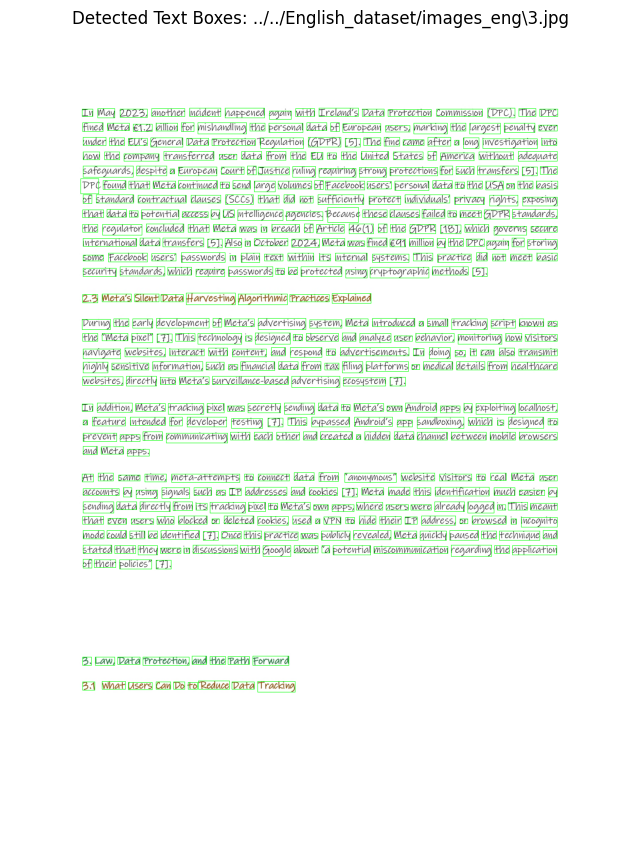

In May 2023, another incident happened again with Lreland’s Data Protection Commission (DPC). The DPC
fined Meta €1.2 billion for mishandling the personal data of European users, marking the largest penalty ever
under the EU's General Data Protection Regulation (GDPR) [5]. The fine came after a long investigation into
how the company transferred user data from the EU to the United States of America without adequate
safeguards, despite a European Court of Justice ruling requiring strong protections for such transfers [5]. The
DPC found that Meta continued to send large volumes of Facebook users’ personal data to the USA on the basis
of standard contractual clauses (SCCs) that did not sufficiently protect individuals’ privacy rights, exposing
that data to potential access by US intelligence agencies. Because these clauses failed +o meet GDPR standards,
the regulator concluded that Meta was in breach of Article 46(1) of the GDFR [18], which governs secure
intemational data transfers [5]. 

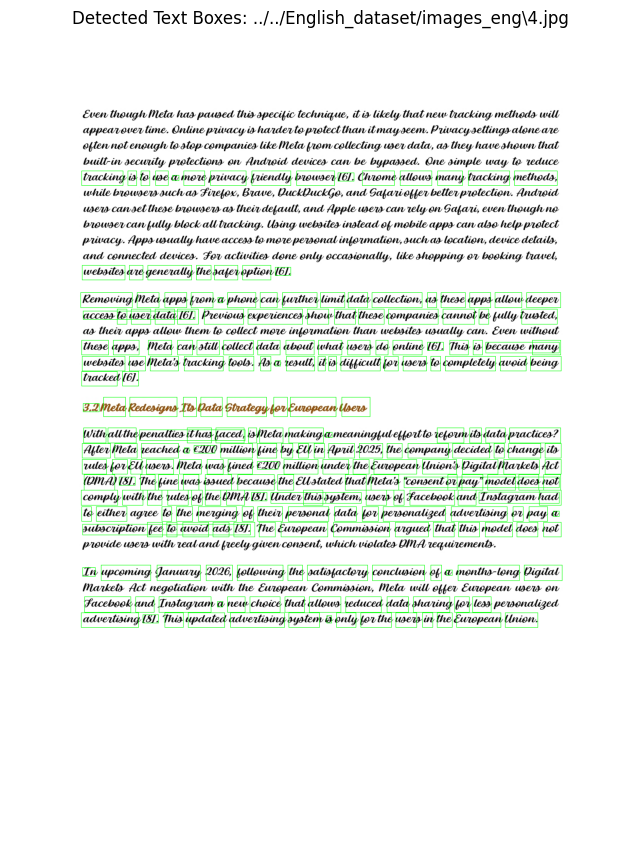

tracking ia to wwe a mere privacy piendly browser [6]. Chiome allows many tracking metheds,
websiles aie generally the safer option [6].

Removing Meta apps fiom a phone can further limit data collection, as these apps allow deeper
access to user data [6]. Previous experiences show that these companies cannot be jully tated,
these apps, Meta can still collect data about what userw de online [6]. This is because many
websiles use Metas tracking tools. As a vesull, it ia difficult Jor users to completely avoid being
tracked [6].

3.2 Meta Redesigns Its Vata Ghategy or European Users

With allthe penalties ithas faced, ie Meta making a meaningsuleffortle vegeum ila data practices?
After Meta veached a €200 million fine by EU in April 2025, the company decided te change its.
wiles pov EU werw. Meta was fined €200 million under the Eurcpean Unions Digital Markets Act
(QINA) [8]. The fine was waued because the Ellatated that Metas ‘consent or pay” medel dees net
comply with the utes of the V

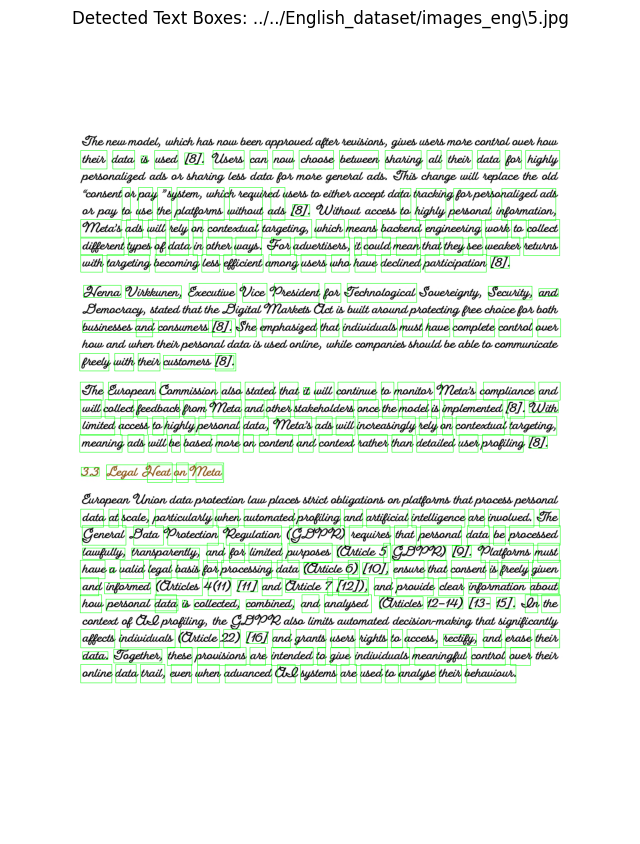

their data i ubed [8]. Users can now choose between sharing all their data for highly
aoay ta tae the pltfouns utheut ads PB) “Wihast ates to highly resent ngornation,
WMeta’s ads will rely on contertuat targeting, which means backend engineering work to. collect
different types of data in other ways. For advertisers, tt could mean that they bee weaker returns
with targeting becoming less efficient amang ubers wha have declined participation [8].

Nenna Virkkunen, Executive Vice President for Technological Sovereignty, Security, and
businesses and consumers [8]. She emphasiged that individuals must have complete canthol over
freely with their customers [8].

The European Commission alsa stated that it will continue ta. monitor Meta’, compliance and
wil collect feedback from Weta and, other stakeholders ance the model is implemented. [8]. With
limited access ta. highly personal data, VNeta’s ads wilt increasingly rely on cantestuat targeting,
meaning ads will be babed moe on content and

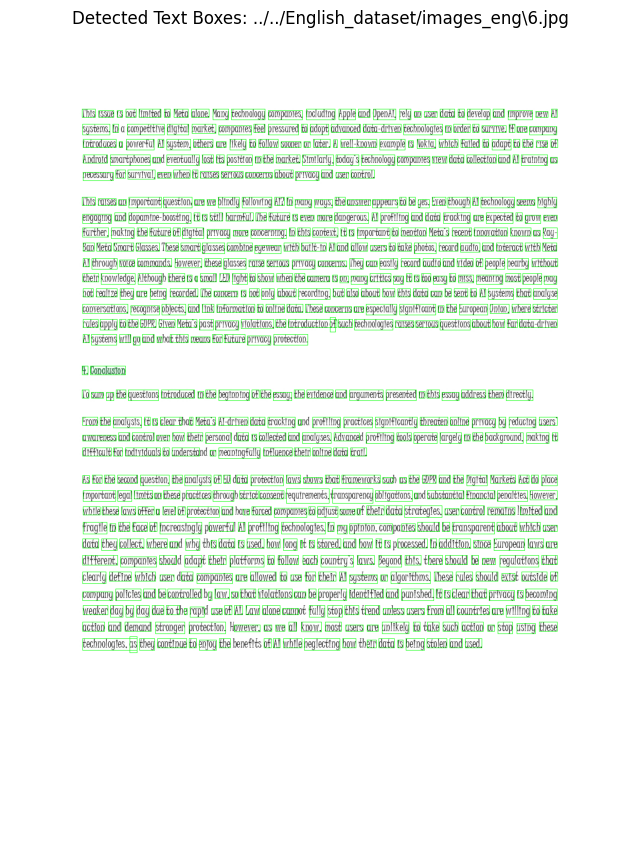

This issue 1s not limited to Meta alone. Many technology companies, including Apple and Opendl, rely on user data to develop and improve new Al
systems. In competitive digital market, compantes feel pressured to adopt advanced data-driven technologies tn order to survive. If one company
Introduces a powerful Al system, others are likely to follow sooner or later. A well-known example ts Nokia, which fatled to adapt to the rise of
Android smartphones and eventually lost 1ts posttion in the market. Similarly, today’s technology companies view data collection and Al training as
necessary for survival, even when Tt ratses serfous concerns about privacy and user control.

This raises an Important question. are we blindly following Al? In many ways, the answer appears to be yes. Even though Al technology seems highly
engaging and dopamine-boosting, rt 1s stil! harmful. The future is even more dangerous. Al profiling and data tracking ane expected to grow even
further, making the future of di

In [73]:
for p in pages:
    print(f"\n==============================")
    print(f"Page {p}")
    print(f"==============================")

    image_path = os.path.join(ENG_IMAGES_DIR,f"{p}.jpg")
    output_path = os.path.join(output_dir, f"page_{p}.txt")

    #show bounding boxes
    draw_bounding_boxes(
        image_path,
        psm=4,
        min_conf=0
    )

    #extract text without preprocessing
    output_text = extract_text_pytesseract(
        image_path,
        psm=4,
        oem=1
    )

    print(output_text)

    with open(output_path, "w", encoding="utf-8") as f:
        f.write(output_text)

    print(f"Saved: {output_path}")

## Evaluation Experiment 1

In [74]:
def normalize_text(text):
    text = text.lower()
    text = text.strip()
    text = re.sub(r"\s+", " ", text)
    return text

In [75]:
results_exp1 = []

for p in pages:
    print(f"Evaluating page {p}...")

    gold_path = os.path.join(ENG_GOLD_DIR, f"{p}.txt")

    with open(gold_path, "r", encoding="utf-8") as f:
        gold_text = f.read()

    pred_path = os.path.join(output_dir, f"page_{p}.txt")

    with open(pred_path, "r", encoding="utf-8") as f:
        pred_text = f.read()

    gold_norm = normalize_text(gold_text)
    pred_norm = normalize_text(pred_text)

    wer_score = wer(gold_norm, pred_norm)
    cer_score = cer(gold_norm, pred_norm)

    results_exp1.append({
        "page": p,
        "WER": wer_score,
        "CER": cer_score
    })

Evaluating page 1...
Evaluating page 2...
Evaluating page 3...
Evaluating page 4...
Evaluating page 5...
Evaluating page 6...


In [76]:
print("=== Experiment 1 Results: Pytesseract - English ===")
df_exp1 = pd.DataFrame(results_exp1)
df_exp1

=== Experiment 1 Results: Pytesseract - English ===


,page,WER,CER
0,1,0.020253,0.003171
1,2,0.025641,0.004447
2,3,0.034858,0.006046
3,4,0.567816,0.459398
4,5,0.441327,0.299688
5,6,0.106061,0.017992


In [78]:
mean_wer = df_exp1["WER"].mean()
mean_cer = df_exp1["CER"].mean()

print("=== Experiment 1 Results - Pytesseract-English ===")
print(f"Mean WER: {mean_wer:.4f}")
print(f"Mean CER: {mean_cer:.4f}")

=== Experiment 1 Results - Pytesseract-English ===
Mean WER: 0.1993
Mean CER: 0.1318


### Save the result

In [79]:
import os

output_dir_result_1 = "outputs/Results"
os.makedirs(output_dir_result_1, exist_ok=True)

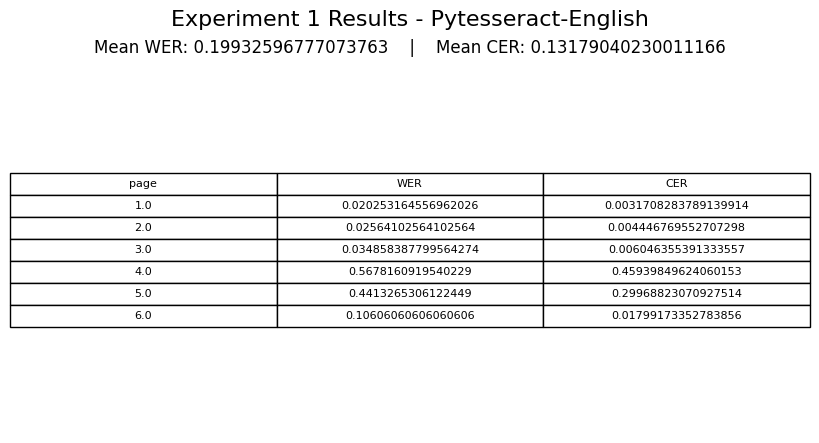

Saved: outputs/Results\experiment_1_results.png


In [80]:
import os
import matplotlib.pyplot as plt

mean_wer = df_exp1["WER"].mean()
mean_cer = df_exp1["CER"].mean()

save_path = os.path.join(output_dir_result_1, "experiment_1_results.png")

fig, ax = plt.subplots(figsize=(10, len(df_exp1) * 0.45 + 2))
ax.axis("off")


fig.suptitle("Experiment 1 Results - Pytesseract-English", fontsize=16, y=0.98)

summary_text = f"Mean WER: {mean_wer}    |    Mean CER: {mean_cer}"
fig.text(0.5, 0.90, summary_text, ha="center", va="center", fontsize=12)

# Table
table = ax.table(
    cellText=df_exp1.values,
    colLabels=df_exp1.columns,
    cellLoc="center",
    colLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 1.3)

ax.set_position([0.1, 0.08, 0.8, 0.78])

fig.savefig(save_path, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
plt.close(fig)

print("Saved:", save_path)

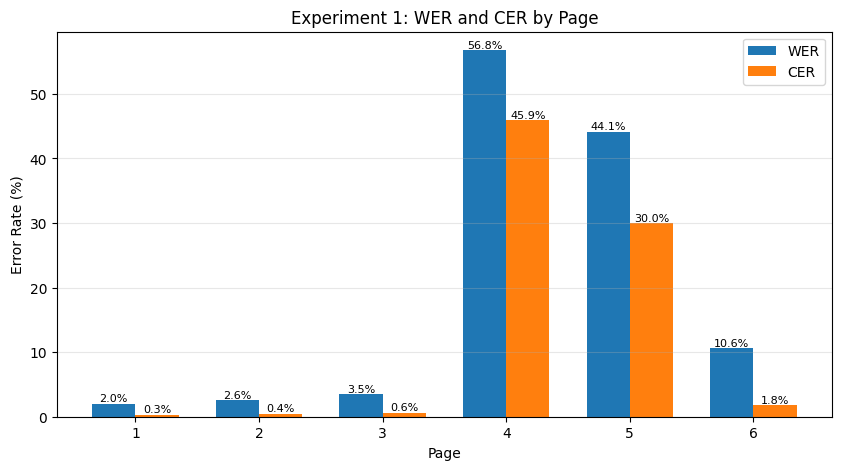

In [81]:
x = np.arange(len(df_exp1))
width = 0.35

wer_pct = df_exp1["WER"] * 100
cer_pct = df_exp1["CER"] * 100

plt.figure(figsize=(10,5))

bars1 = plt.bar(x - width/2, wer_pct, width, label="WER")
bars2 = plt.bar(x + width/2, cer_pct, width, label="CER")

for bar in bars1:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.1f}%",
        ha="center",
        va="bottom",
        fontsize=8
    )

for bar in bars2:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.1f}%",
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.xticks(x, df_exp1["page"])
plt.xlabel("Page")
plt.ylabel("Error Rate (%)")
plt.title("Experiment 1: WER and CER by Page")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

#### 2. OCR Confidence Score Analysis
- Does Tesseract's confidence score actually reflect OCR quality?

  
In addition to Word Error Rate (WER) and Character Error Rate (CER), Tesseract provides confidence scores for recognized text. These scores indicate how confident the OCR engine is in its predictions.

For each page, the average confidence score is calculated from all detected words. The relationship between confidence scores and OCR performance is then analyzed by comparing confidence against WER and CER.

If confidence scores increase while WER and CER decrease, the correlation will be negative. This means that pages with higher confidence generally produce more accurate OCR results.

Correlation values range from -1 to +1:

- Correlation close to -1: Strong relationship. Higher confidence is strongly associated with lower OCR errors.
- Correlation close to 0: Little or no relationship. Confidence scores do not reliably reflect OCR accuracy.
- Correlation close to +1: Opposite relationship. Higher confidence is associated with higher OCR errors, which would indicate that confidence scores are misleading.

In [83]:
confidence_results = []

for p in pages:

    image = cv2.imread(
        os.path.join(
            ENG_IMAGES_DIR,
            f"{p}.jpg"
        )
    )

    data = pytesseract.image_to_data(
        image,
        lang="eng",
        config="--oem 1 --psm 4",
        output_type=pytesseract.Output.DICT
    )

    confidences = [
        float(c)
        for c in data["conf"]
        if c != "-1"
    ]

    avg_conf = np.mean(confidences)

    confidence_results.append({
        "page": p,
        "avg_confidence": avg_conf
    })

confidence_df = pd.DataFrame(confidence_results)

confidence_df

,page,avg_confidence
0,1,85.392290
1,2,86.338583
2,3,81.695050
3,4,68.253571
4,5,69.186916
5,6,82.206259


In [48]:
analysis_df = df_exp1.merge(
    confidence_df,
    on="page"
)

analysis_df

,page,WER,CER,avg_confidence
0,1,0.020253,0.003171,85.392290
1,2,0.025641,0.004447,86.338583
2,3,0.034858,0.006046,81.695050
3,4,0.567816,0.459398,68.253571
4,5,0.441327,0.299688,69.186916
5,6,0.668421,0.503922,82.206259


##### Observations(Confidence Score Analysis)

The correlation between average confidence and WER was -0.629, while the correlation between average confidence and CER was -0.626.

These values indicate a moderately strong negative relationship between confidence and OCR errors. In general, pages with higher confidence scores produced lower WER and CER values, suggesting that Tesseract confidence scores are reasonably good indicators of OCR quality.

However, the correlation is not close to -1, meaning that confidence scores are not perfect predictors of OCR accuracy. Some pages may still receive relatively high confidence scores despite containing recognition errors.

In [84]:
print("Correlation: Confidence vs WER")
print(analysis_df["avg_confidence"].corr(analysis_df["WER"]))

print("Correlation: Confidence vs CER")
print(analysis_df["avg_confidence"].corr(analysis_df["CER"]))

Correlation: Confidence vs WER
-0.62935141520758
Correlation: Confidence vs CER
-0.6259881118137451


##### Observations(Confidence Score Analysis-Plot)
- Higher confidence scores are generally associated with lower OCR error rates.
- However, the relationship is not perfect, as some pages receive high confidence.despite producing substantial OCR errors.

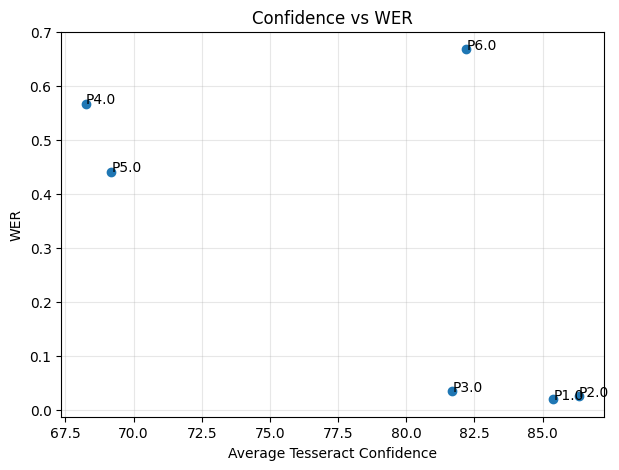

In [85]:
plt.figure(figsize=(7,5))

plt.scatter(
    analysis_df["avg_confidence"],
    analysis_df["WER"]
)

for _, row in analysis_df.iterrows():
    plt.annotate(
        f"P{row['page']}",
        (row["avg_confidence"], row["WER"])
    )

plt.xlabel("Average Tesseract Confidence")
plt.ylabel("WER")
plt.title("Confidence vs WER")
plt.grid(True, alpha=0.3)
plt.show()

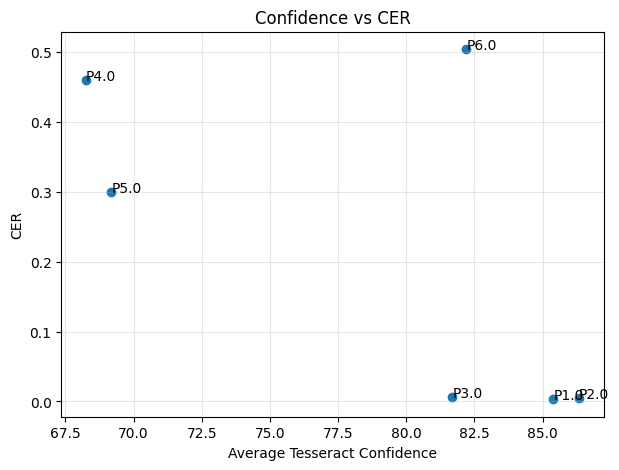

In [86]:
plt.figure(figsize=(7,5))

plt.scatter(
    analysis_df["avg_confidence"],
    analysis_df["CER"]
)

for _, row in analysis_df.iterrows():
    plt.annotate(
        f"P{row['page']}",
        (row["avg_confidence"], row["CER"])
    )

plt.xlabel("Average Tesseract Confidence")
plt.ylabel("CER")
plt.title("Confidence vs CER")

plt.grid(True, alpha=0.3)
plt.show()

#### 3. Distribution of Tesseract Confidence Scores

- How are confidence scores distributed across all detected words?

This section analyzes the distribution of word-level confidence scores produced by Tesseract. Instead of using only the average confidence score per page, this analysis collects confidence values for all detected words across the dataset.

A histogram is used to show how many detected words fall into different confidence ranges. If most values are close to 100, Tesseract was generally confident in its recognition. If many values are low, it suggests that the OCR engine struggled with difficult fonts, unclear text, or layout problems.

In [105]:
all_confidences = []

for p in pages:
    image_path = os.path.join(
        ENG_IMAGES_DIR,
        f"{p}.jpg"
    )

    image = cv2.imread(image_path)

    data = pytesseract.image_to_data(
        image,
        lang="eng",
        config="--oem 1 --psm 4",
        output_type=pytesseract.Output.DICT
    )

    for conf in data["conf"]:
        try:
            conf_value = float(conf)

            if conf_value >= 0:
                all_confidences.append(conf_value)

        except:
            pass

print(f"Total confidence values collected: {len(all_confidences)}")

Total confidence values collected: 2636


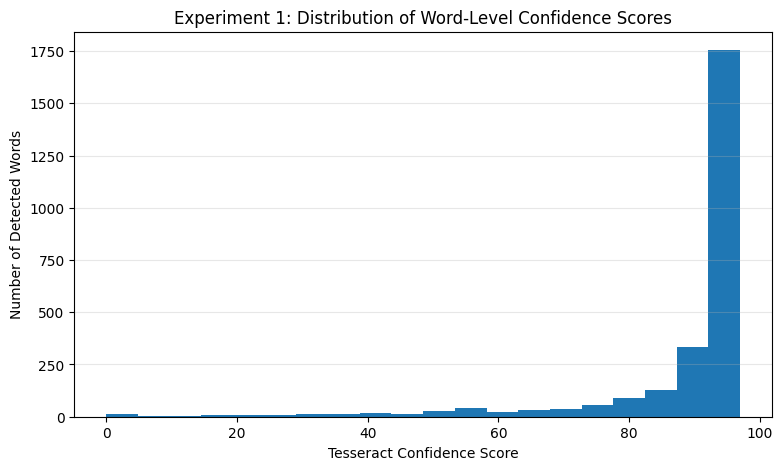

In [106]:
plt.figure(figsize=(9,5))

plt.hist(
    all_confidences,
    bins=20
)

plt.xlabel("Tesseract Confidence Score")
plt.ylabel("Number of Detected Words")
plt.title("Experiment 1: Distribution of Word-Level Confidence Scores")

plt.grid(axis="y", alpha=0.3)

plt.show()

In [107]:
print(f"Mean confidence: {np.mean(all_confidences):.2f}")
print(f"Median confidence: {np.median(all_confidences):.2f}")
print(f"Minimum confidence: {np.min(all_confidences):.2f}")
print(f"Maximum confidence: {np.max(all_confidences):.2f}")

Mean confidence: 88.43
Median confidence: 95.00
Minimum confidence: 0.00
Maximum confidence: 97.00


##### Observation (Confidence Score Distribution)

The histogram shows that most detected words received confidence scores between 90 and 97. Only a small number of words were assigned low confidence values, creating a left tail in the distribution. This indicates that Tesseract was highly confident for the majority of recognized words.

The median confidence score (95) is higher than the mean confidence score (88.43), suggesting that a few low-confidence recognitions reduced the overall average. Therefore, OCR uncertainty appears to be concentrated in a limited number of difficult words rather than affecting the entire document.

#### 4. Word Detection Rate

Word Detection Rate compares the number of words in the gold-standard text with the number of words produced by PyTesseract. The word detection rate shows whether the OCR system extracted too few, too many, or approximately the correct number of words.

A value close to 100% means that the OCR output contains a similar number of words as the gold standard. A value below 100% suggests that some words may have been missed, while a value above 100% may indicate extra or incorrectly split words.

In [90]:
word_detection_results = []

for p in pages:
    gold_path = os.path.join(ENG_GOLD_DIR, f"{p}.txt")
    pred_path = os.path.join(output_dir, f"page_{p}.txt")

    with open(gold_path, "r", encoding="utf-8") as f:
        gold_text = f.read()

    with open(pred_path, "r", encoding="utf-8") as f:
        pred_text = f.read()

    gold_norm = normalize_text(gold_text)
    pred_norm = normalize_text(pred_text)

    gold_words = len(gold_norm.split())
    ocr_words = len(pred_norm.split())

    detection_rate = (ocr_words / gold_words) * 100 if gold_words > 0 else 0

    page_wer = df_exp1.loc[
        df_exp1["page"] == p,
        "WER"
    ].values[0]

    word_detection_results.append({
        "page": p,
        "Gold Words": gold_words,
        "OCR Words": ocr_words,
        "WER": page_wer,
        "Word Detection Rate (%)": detection_rate
    })

word_detection_df = pd.DataFrame(word_detection_results)

word_detection_df

,page,Gold Words,OCR Words,WER,Word Detection Rate (%)
0,1,395,394,0.020253,99.746835
1,2,585,585,0.025641,100.000000
2,3,459,459,0.034858,100.000000
3,4,435,251,0.567816,57.701149
4,5,392,288,0.441327,73.469388
5,6,660,659,0.106061,99.848485


##### Observations(Word Detection Rate)
Page 6 achieved a Word Detection Rate of 99.85%, indicating that almost all words were successfully detected by Tesseract. However, the WER of 10.6% shows that some detected words were recognized incorrectly. This demonstrates that a high detection rate does not necessarily imply perfect recognition accuracy, as OCR may locate words correctly while still producing transcription errors.

#### 5. OCR Speed Analysis

We will measure how long PyTesseract takes to process each page in Experiment 1. Runtime is calculated separately for every image, and then the average and total processing time are reported.This helps evaluate not only OCR accuracy, but also processing efficiency.

In [91]:
import time

ocr_speed_results = []

for p in pages:
    image_path = os.path.join(
        ENG_IMAGES_DIR,
        f"{p}.jpg"
    )

    start_time = time.time()

    output_text = extract_text_pytesseract(
        image_path,
        psm=4,
        oem=1
    )

    end_time = time.time()

    elapsed_time = end_time - start_time

    ocr_speed_results.append({
        "page": p,
        "OCR Time (seconds)": elapsed_time
    })

ocr_speed_df = pd.DataFrame(ocr_speed_results)

ocr_speed_df

,page,OCR Time (seconds)
0,1,1.371403
1,2,1.429750
2,3,1.438170
3,4,1.082544
4,5,1.359697
5,6,1.497695


In [92]:
average_time = ocr_speed_df["OCR Time (seconds)"].mean()
total_time = ocr_speed_df["OCR Time (seconds)"].sum()

print(f"Average OCR time per page: {average_time:.3f} seconds")
print(f"Total OCR time for Experiment 1: {total_time:.3f} seconds")

Average OCR time per page: 1.363 seconds
Total OCR time for Experiment 1: 8.179 seconds


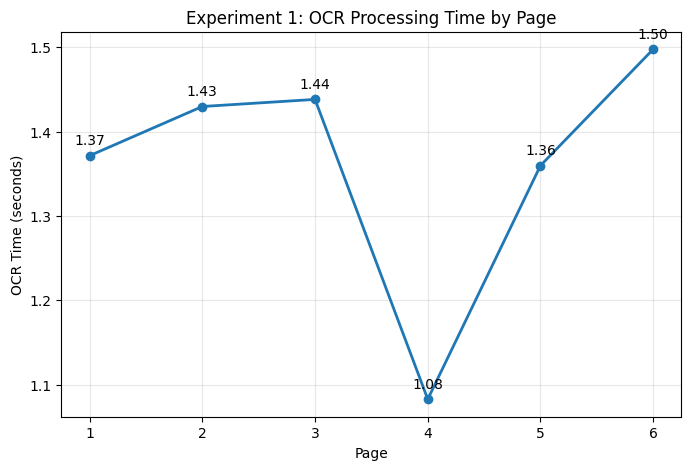

In [96]:
plt.figure(figsize=(8,5))

plt.plot(
    ocr_speed_df["page"],
    ocr_speed_df["OCR Time (seconds)"],
    marker="o",
    linewidth=2
)

for _, row in ocr_speed_df.iterrows():
    plt.annotate(
        f'{row["OCR Time (seconds)"]:.2f}',
        (
            row["page"],
            row["OCR Time (seconds)"]
        ),
        xytext=(0,8),
        textcoords="offset points",
        ha="center"
    )

plt.xlabel("Page")
plt.ylabel("OCR Time (seconds)")
plt.title("Experiment 1: OCR Processing Time by Page")

plt.xticks(ocr_speed_df["page"])
plt.grid(True, alpha=0.3)

plt.show()

In [97]:
speed_analysis_df = (
    word_detection_df[
        ["page", "WER", "Word Detection Rate (%)"]
    ]
    .merge(
        ocr_speed_df,
        on="page"
    )
)

speed_analysis_df

,page,WER,Word Detection Rate (%),OCR Time (seconds)
0,1,0.020253,99.746835,1.371403
1,2,0.025641,100.000000,1.429750
2,3,0.034858,100.000000,1.438170
3,4,0.567816,57.701149,1.082544
4,5,0.441327,73.469388,1.359697
5,6,0.106061,99.848485,1.497695


##### Observation(OCR Speed Analysis)
A tendency can be observed where pages with lower word detection rates were processed faster by Tesseract. For example, Page 4 had the lowest detection rate (57.7%) and the shortest OCR time (1.08 s), while pages with nearly complete word detection required slightly more processing time.

At the same time, Variations in runtime may be influenced by factors such as page complexity, text density, image dimensions, and font characteristics. Pages with higher text density may require slightly longer processing times.

#### 6. Page-Level Performance Ranking

Pages can be ranked according to their OCR performance using Word Error Rate (WER). Lower WER values indicate better OCR quality, while higher WER values indicate greater recognition errors. This ranking helps identify which pages were easiest and most difficult for Tesseract to process.

In [108]:
ranking_df = df_exp1.sort_values(
    by="WER",
    ascending=True
).reset_index(drop=True)

ranking_df["Rank"] = ranking_df.index + 1

ranking_df = ranking_df[
    ["Rank", "page", "WER", "CER"]
]

ranking_df

,Rank,page,WER,CER
0,1,1,0.020253,0.003171
1,2,2,0.025641,0.004447
2,3,3,0.034858,0.006046
3,4,6,0.106061,0.017992
4,5,5,0.441327,0.299688
5,6,4,0.567816,0.459398


In [109]:
ranking_df = (
    df_exp1
    .merge(
        confidence_df,
        on="page"
    )
    .sort_values(
        by="WER",
        ascending=True
    )
    .reset_index(drop=True)
)

ranking_df["Rank"] = ranking_df.index + 1

ranking_df = ranking_df[
    [
        "Rank",
        "page",
        "WER",
        "CER",
        "avg_confidence"
    ]
]

ranking_df

,Rank,page,WER,CER,avg_confidence
0,1,1,0.020253,0.003171,85.392290
1,2,2,0.025641,0.004447,86.338583
2,3,3,0.034858,0.006046,81.695050
3,4,6,0.106061,0.017992,82.206259
4,5,5,0.441327,0.299688,69.186916
5,6,4,0.567816,0.459398,68.253571


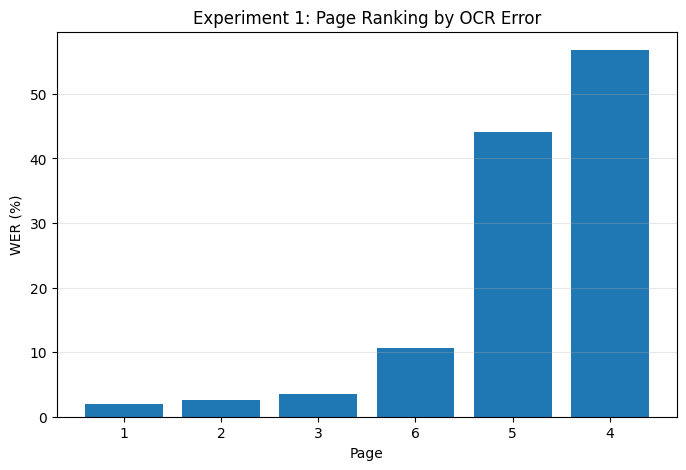

In [111]:
plt.figure(figsize=(8,5))

plt.bar(
    ranking_df["page"].astype(str),
    ranking_df["WER"] * 100
)

plt.xlabel("Page")
plt.ylabel("WER (%)")
plt.title("Experiment 1: Page Ranking by OCR Error")

plt.grid(axis="y", alpha=0.3)

plt.show()